⚠️ 'outputs/cleaned_data/cleaned_deliveries.csv' was empty or missing.
👉 Safely falling back to raw data stream: C:\Users\Admin\IPL-DataAnalysis\IPL-Data-Analysis\data\deliveries.csv
⚡ Running High-Performance Dictionary Mapping Optimization...
🏏 EXECUTING SITUATIONAL SPLITS & PERFORMANCE METRICS

Calculating Powerplay Strike Rates (Overs 1-6)...


C:\Users\Admin\AppData\Local\Temp\ipykernel_11852\1438795901.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pp_hitters, x='pp_strike_rate', y='batter', palette='rocket')


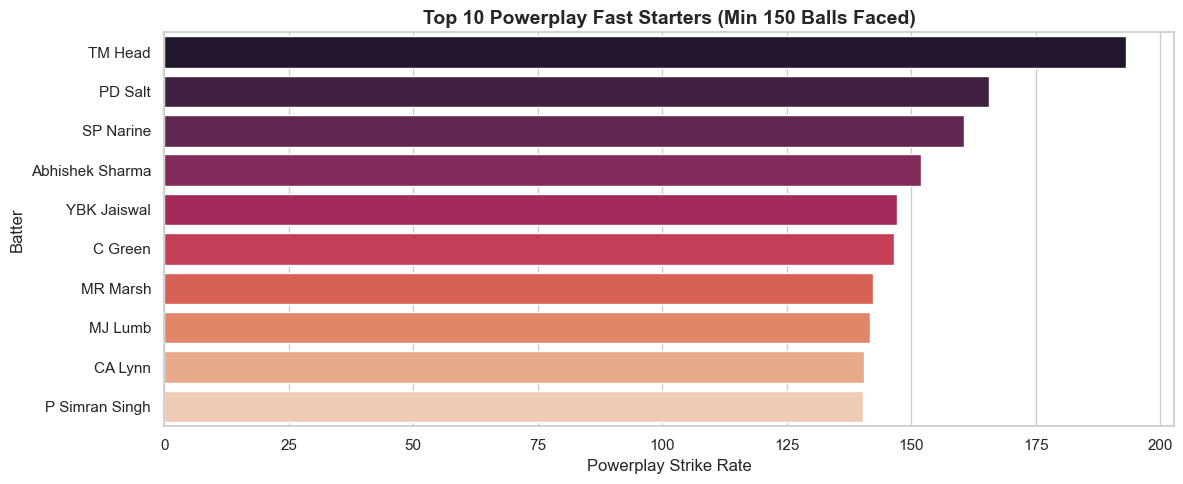


Calculating Death Overs Dominance Profiles (Overs 16-20)...


C:\Users\Admin\AppData\Local\Temp\ipykernel_11852\1438795901.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_death_finishers, x='death_strike_rate', y='batter', palette='mako')


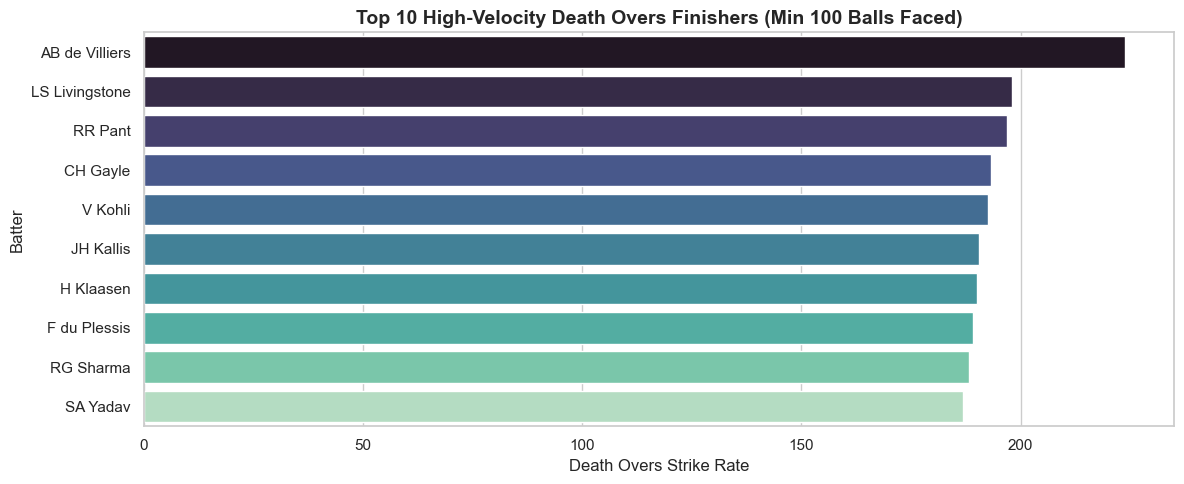


⚙️ RUNNING PRODUCTION AGGREGATION EXPORT LAYER
✔️ Aggregation Written: team_performance.csv
✔️ Aggregation Written: player_stats.csv

🎉 Success! All optimizations complete and files exported cleanly.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup professional visualization formatting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Absolute Path Initializer
BASE_DIR = r"C:\Users\Admin\IPL-DataAnalysis\IPL-Data-Analysis"
MATCHES_PATH = os.path.join(BASE_DIR, "outputs", "cleaned_data", "cleaned_matches.csv")
DELIVERIES_PATH = os.path.join(BASE_DIR, "outputs", "cleaned_data", "cleaned_deliveries.csv")

matches = pd.read_csv(MATCHES_PATH)

# Bulletproof Data Loading Fallback Engine
if os.path.exists(DELIVERIES_PATH) and os.path.getsize(DELIVERIES_PATH) > 0:
    deliveries = pd.read_csv(DELIVERIES_PATH)
else:
    raw_deliveries_path = os.path.join(BASE_DIR, "data", "deliveries.csv")
    print(f"⚠️ 'outputs/cleaned_data/cleaned_deliveries.csv' was empty or missing.")
    print(f"👉 Safely falling back to raw data stream: {raw_deliveries_path}")
    deliveries = pd.read_csv(raw_deliveries_path)

print("⚡ Running High-Performance Dictionary Mapping Optimization...")
# OPTIMIZATION: Instead of merging heavy tables, create a lightweight dictionary lookup map
season_map = dict(zip(matches['id'], matches['season']))

# Instantly map the season to each ball-by-ball row using the index map
deliveries['season'] = deliveries['match_id'].map(season_map)

print("="*60)
print("🏏 EXECUTING SITUATIONAL SPLITS & PERFORMANCE METRICS")
print("="*60)

# --- SITUATIONAL SPLIT 1: POWERPLAY ACCELERATION (Overs 1-6) ---
print("\nCalculating Powerplay Strike Rates (Overs 1-6)...")
# Filter down the rows BEFORE grouping to keep things lightning-fast
pp_df = deliveries[deliveries['over'] <= 6]
pp_stats = pp_df.groupby('batter').agg(
    pp_runs=('batsman_runs', 'sum'),
    pp_balls=('batsman_runs', 'count')
).reset_index()

pp_stats = pp_stats[pp_stats['pp_balls'] >= 150]
pp_stats['pp_strike_rate'] = (pp_stats['pp_runs'] / pp_stats['pp_balls']) * 100
top_pp_hitters = pp_stats.sort_values(by='pp_strike_rate', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_pp_hitters, x='pp_strike_rate', y='batter', palette='rocket')
plt.title('Top 10 Powerplay Fast Starters (Min 150 Balls Faced)', fontsize=14, fontweight='bold')
plt.xlabel('Powerplay Strike Rate')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

# --- SITUATIONAL SPLIT 2: DEATH OVERS FINISHING EFFICIENCY (Overs 16-20) ---
print("\nCalculating Death Overs Dominance Profiles (Overs 16-20)...")
death_df = deliveries[deliveries['over'] > 15]
death_stats = death_df.groupby('batter').agg(
    death_runs=('batsman_runs', 'sum'),
    death_balls=('batsman_runs', 'count')
).reset_index()

death_stats = death_stats[death_stats['death_balls'] >= 100]
death_stats['death_strike_rate'] = (death_stats['death_runs'] / death_stats['death_balls']) * 100
top_death_finishers = death_stats.sort_values(by='death_strike_rate', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_death_finishers, x='death_strike_rate', y='batter', palette='mako')
plt.title('Top 10 High-Velocity Death Overs Finishers (Min 100 Balls Faced)', fontsize=14, fontweight='bold')
plt.xlabel('Death Overs Strike Rate')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

# --- PART 2: PRODUCTION AGGREGATION PIPELINE (Dashboard Exports) ---
print("\n" + "="*60)
print("⚙️ RUNNING PRODUCTION AGGREGATION EXPORT LAYER")
print("="*60)

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "aggregations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

team_perf_summary = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
team_perf_summary.to_csv(os.path.join(OUTPUT_DIR, "team_performance.csv"), index=False)
print("✔️ Aggregation Written: team_performance.csv")

# Generate player runs aggregation instantly using mapped series
player_run_summary = deliveries.groupby(['season', 'batter'])['batsman_runs'].sum().reset_index()
player_run_summary.columns = ['season', 'batsman', 'batsman_runs']
player_run_summary.to_csv(os.path.join(OUTPUT_DIR, "player_stats.csv"), index=False)
print("✔️ Aggregation Written: player_stats.csv")

print("\n🎉 Success! All optimizations complete and files exported cleanly.")